# Proyecto - Computación Avanzada

## Tema: Aprendizaje de refuerzo en sistemas correlacionados en el tiempo usando redes neuronales

In [1]:
from pesca_2D_env import Pesca2D
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env

In [2]:
#Factor de crecimiento de cada poblacion
r_p = 1
r_d = 0.2

#Factor de ruido agregado al sistema
sigma=0.05

#Poblacion inicial de cada especie
init_B_p = 0.4
init_B_d = 0.7

#Factor T (revisar que hace)
T = 200

#Factor de mortalidad de cada especie
m_p = 0.1 #Probar distintos valores 0.1 - 1 - 1.5
m_d = 0.

#Factor que limita el valor maximo de la poblacion depredadora
C = 1

#Diccionario con los parametros del env
params = { "r_crecimiento": np.array([r_p, r_d]),
           "sigma": sigma,
           "init_B": np.array([init_B_p, init_B_d]),
           "T": T,
           "mortalidad": np.array([m_p, m_d]),
           "C": C,
           "epsilon": 1e-5
}

#Inicializa el ambiente
env = Pesca2D(params)

In [3]:
#Inicializa el modelo
agent = PPO("MlpPolicy", env, verbose=1)

#Entrena el modelo
agent.learn(total_timesteps=25000)

#Guarda el modelo
agent.save("ppo_pesca_2D")

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/home/migue/micromamba/envs/basico/lib/python3.12/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


[0.4 0.7]
0.05
-0.4603978612824606
[0.4 0.7]
0.05
-1.5187607432793415
[0.4 0.7]
0.05
-1.814861972971544
[0.4 0.7]
0.05
-0.5053867757449696
[0.4 0.7]
0.05
-0.06439526304944436
[0.4 0.7]
0.05
-0.18564190288319743
[0.4 0.7]
0.05
-0.27817116983353246
[0.4 0.7]
0.05
-0.23741179329870596
[0.4 0.7]
0.05
-1.1042145527868368
[0.4 0.7]
0.05
0.40767199287525224
[0.4 0.7]
0.05
-0.4253232190311655
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | 28       |
| time/              |          |
|    fps             | 515      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 2048     |
---------------------------------
[0.4 0.7]
0.05
-1.025698096382288
[0.4 0.7]
0.05
-1.8685973886198137
[0.4 0.7]
0.05
0.16919847429563745
[0.4 0.7]
0.05
-1.9897168476303244
[0.4 0.7]
0.05
0.04279576527116947
[0.4 0.7]
0.05
-0.3701925769666025
[0.4 0.7]
0.05
0.8544076176786147
[0.4 0.7]
0.05
1.013755737600

In [4]:
#Carga el modelo (para evitar correr el entrenamiento todas las veces)
agent = PPO.load("ppo_pesca_2D")

In [5]:
#Cantidad de steps
N = 200

#Reinicia el sistema y obtiene la observación inicial
obs, _ = env.reset()

#Listas para guardar la población y el harvest
presa = np.zeros(N)
depredador = np.zeros(N)
harvest = np.zeros(N)

for i in range(N):
    #El agente define una accion segun la observación
    action, _ = agent.predict(obs, deterministic=True)
    # action = np.array([-1])

    #Calcula un step del environment segun la acción
    obs, reward, terminated, truncated, _ = env.step(action)

    #Registra la población de cada paso
    presa[i] = env.unnormalize(obs[0])
    depredador[i] = env.unnormalize(obs[1])

    #Registra los rewards de cada paso
    harvest[i] = reward

## Resultados: Evolución temporal de la población y del harvest

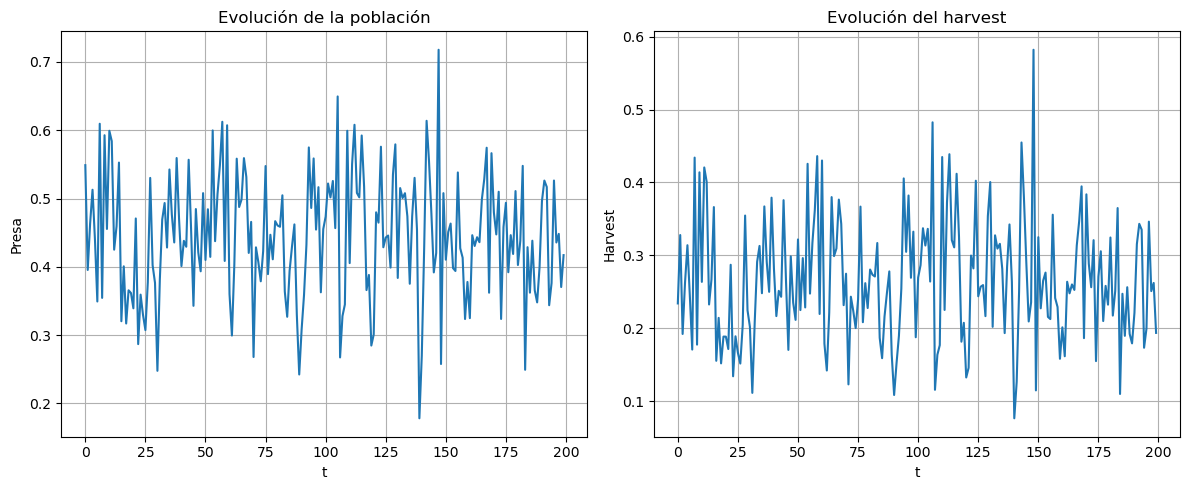

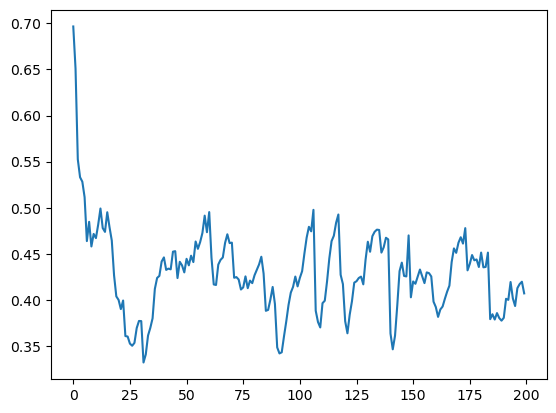

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Gráfica de población
axs[0].plot(presa)
axs[0].set_xlabel("t")
axs[0].set_ylabel("Presa")
axs[0].set_title("Evolución de la población")
axs[0].grid(True)

# Gráfica de harvest
axs[1].plot(harvest)
axs[1].set_xlabel("t")
axs[1].set_ylabel("Harvest")
axs[1].set_title("Evolución del harvest")
axs[1].grid(True)

plt.tight_layout()
plt.show()

plt.plot(depredador)

## Resultados: Población (Biomasa) en función del harvest (mortalidad por pesca)

In [7]:
#Define la biomasa como un array en el dominio de [0,1]
M = 100
biomass = np.linspace(0, 1, M)

#Crea un array para guardar las acciones del agente
actions = np.zeros(M)

for i in range(M):
    #Normaliza la observacion al formato necesario de -1 a 1
    obs = np.array([-1 + 2*biomass[i]])

    #El agenre da una accion en funcion de la observacion (cantidad de biomasa)
    action, _ = agent.predict(obs,deterministic=True)

    #Desnormaliza y guarda la accion en el dominio de 0 a 1
    actions[i] = (action[0] +1)/2

#Grafica el resultado
plt.plot(biomass, actions)
plt.xlabel("Biomasa")
plt.ylabel("Mortalidad por pesca")
plt.grid(True)
plt.show()

ValueError: Error: Unexpected observation shape (1,) for Box environment, please use (2,) or (n_env, 2) for the observation shape.

### Análisis:

La mortalidad aumenta en función de la biomasa, lo cual tiene sentido, ya que si hay más peces, nos podemos permitir pescar más. Otro detalle importante es que, para poblaciones muy bajas, la pesca se detiene por completo, permitiendo al sistema recuperar biomasa hasta alcanzar una población más estable y evitar la extinción completa de la biomasa.